In [ ]:
import csv
import numpy as np
import pandas as pd
import matplotlib as plt

Saved 144 rows to battwatts_sensitivity_load_summary.csv
[{'state_long': 'alabama', 'state_short': 'AL', 'utility': 'apc', 'building_id': '46496', 'latitude': '33.56', 'longitude': '-86.75', 'year': 2018, 'run_type': 'tmy', 'annual_energy': np.float64(11472.694900807812)}, {'state_long': 'alabama', 'state_short': 'AL', 'utility': 'apc', 'building_id': '46496', 'latitude': '33.56', 'longitude': '-86.75', 'year': 2018, 'run_type': 'amy', 'annual_energy': np.float64(11472.694900807812)}, {'state_long': 'alabama', 'state_short': 'AL', 'utility': 'apc', 'building_id': '46496', 'latitude': '33.56', 'longitude': '-86.75', 'year': 2019, 'run_type': 'tmy', 'annual_energy': np.float64(11894.363219122708)}, {'state_long': 'alabama', 'state_short': 'AL', 'utility': 'apc', 'building_id': '46496', 'latitude': '33.56', 'longitude': '-86.75', 'year': 2019, 'run_type': 'amy', 'annual_energy': np.float64(11894.363219122708)}, {'state_long': 'alabama', 'state_short': 'AL', 'utility': 'apc', 'building_id'

In [ ]:
state_long = ["alabama","arizona","california","colorado","massachusetts","minnesota","newyork","ohio","oregon","texas","vermont","wisconsin"] #states in sensitivity analysis
state_short = ["AL","AZ","CA","CO","MA","MN","NY","OH","OR","TX","VT","WI"] #states in sensitivity analysis (abbreviated)
utility_names = ["apc","aps","sdge","xcel","nationalgrid","xcel","coned","aep","pge","xcel","gmp","we_energies"]
building_id = ["46496","112157","111549","126745","305","442412","404322","448494","67263","168160","1652","467842"]
latitude = ["33.56","35.14","32.87","39.81","41.88","44.85","40.68","39.99","45.59","35.22","44.47","42.95"]
longitude = ["-86.75","-111.67","-117.15","-105.14","-71.02","-93.03","-74.17","-82.88","-122.6","-101.71","-73.15","-87.9"]
years = [2018, 2019, 2020, 2021, 2022, 2023]
all_results = []

for st_long, st_short, utility, bd_id, lat, lon in zip(
    state_long, state_short, utility_names, building_id, latitude, longitude
):
    for year in years:
        building_path = "building_models\\bldg" + bd_id + "-up00\\"
        load_path = building_path + str(year) + "-" + bd_id + "_kw_load.csv"

        df = pd.read_csv(load_path)

        annual_energy = sum(df["kW"].values)

        result_row = {
            "state_long": st_long,
            "state_short": st_short,
            "utility": utility,
            "building_id": bd_id,
            "latitude": lat,
            "longitude": lon,
            "year" : year,
            "run_type": "tmy",
            "annual_energy" : annual_energy 
        }
        all_results.append(result_row)

        result_row = {
            "state_long": st_long,
            "state_short": st_short,
            "utility": utility,
            "building_id": bd_id,
            "latitude": lat,
            "longitude": lon,
            "year" : year,
            "run_type": "amy",
            "annual_energy" : annual_energy 
        }
        all_results.append(result_row)


output_file = "battwatts_sensitivity_load_summary.csv"
keys = all_results[0].keys()  # use first result's keys as headers

with open(output_file, 'w', newline='', encoding='utf-8-sig') as f:
    writer = csv.DictWriter(f, fieldnames=keys)
    writer.writeheader()
    writer.writerows(all_results)

print(f"Saved {len(all_results)} rows to {output_file}")
print(all_results)

In [18]:
df_w_batt = pd.read_csv("battwatts_sensitivity_outputs_w_batt.csv")

df_no_batt = pd.read_csv("battwatts_sensitivity_outputs_pv_only.csv")

tmy_w_batt = df_w_batt.query("run_type == 'tmy'")
amy_w_batt = df_w_batt.query("run_type == 'amy'")

tmy_no_batt = df_no_batt.query("run_type == 'tmy'")
amy_no_batt = df_no_batt.query("run_type == 'amy'")

tmy_w_batt = df_w_batt.query("run_type == 'tmy'").reset_index(drop=True)
amy_w_batt = df_w_batt.query("run_type == 'amy'").reset_index(drop=True)

tmy_no_batt = df_no_batt.query("run_type == 'tmy'").reset_index(drop=True)
amy_no_batt = df_no_batt.query("run_type == 'amy'").reset_index(drop=True)

savings_diff_batt = (tmy_w_batt["savings_year1"] - amy_w_batt["savings_year1"]) / amy_w_batt["savings_year1"]
savings_diff_no_batt = (tmy_no_batt["savings_year1"] - amy_no_batt["savings_year1"]) / amy_no_batt["savings_year1"]

<Axes: >

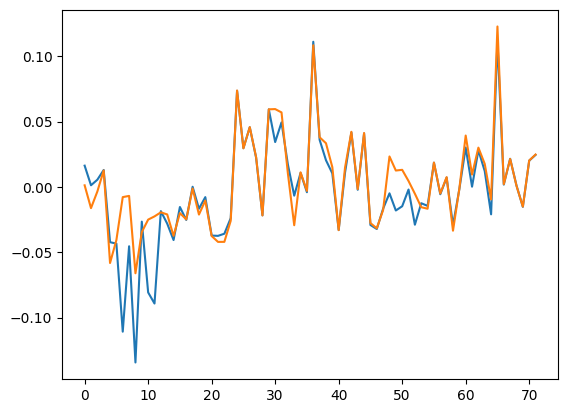

In [ ]:
savings_diff_batt.plot()
savings_diff_no_batt.plot()


